Quick Analysis

In [1]:
# Quick Analysis setup with selectable ticker and year.
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# --- User inputs (edit these) ---
ticker_symbol = 'SPYM'
data_year = 2026

ticker_symbol = ticker_symbol.strip().upper()
if not ticker_symbol:
    raise ValueError('ticker_symbol cannot be empty')

if not isinstance(data_year, int):
    raise ValueError('data_year must be an integer like 2026')

# Resolve the repository root from common working directories.
repo_candidates = [Path('.'), Path('..'), Path('../..')]
repo_root = next((p for p in repo_candidates if (p / 'data' / 'tickers').exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find 'data/tickers' from current working directory.")

tickers_root = repo_root / 'data' / 'tickers'
available_tickers = sorted(
    p.name for p in tickers_root.iterdir() if p.is_dir() and p.name.isalpha()
)

if ticker_symbol not in available_tickers:
    preview = ', '.join(available_tickers[:20])
    raise ValueError(
        f"Ticker '{ticker_symbol}' not found under {tickers_root}. "
        f"Sample available tickers: {preview}"
    )

csv_path = tickers_root / ticker_symbol / f'{ticker_symbol}-{data_year}.csv'
if not csv_path.exists():
    available_years = sorted(
        p.stem.split('-')[-1]
        for p in (tickers_root / ticker_symbol).glob(f'{ticker_symbol}-*.csv')
        if '-' in p.stem
    )
    raise FileNotFoundError(
        f"Data file not found: {csv_path}. "
        f"Available years for {ticker_symbol}: {available_years}"
    )

df = pd.read_csv(csv_path)
required_columns = {'Date', 'avg_daily_price', 'Close', 'Weekday'}
missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Ticker: {ticker_symbol}')
print(f'Loaded {len(df)} rows from: {csv_path}')
df[['Date', 'Weekday', 'avg_daily_price', 'Close']].head()

Ticker: SPYM
Loaded 74 rows from: ..\data\tickers\SPYM\SPYM-2026.csv


,Date,Weekday,avg_daily_price,Close
0,2026-01-02,Friday,80.2733,80.191025
1,2026-01-05,Monday,80.6998,80.719711
2,2026-01-06,Tuesday,80.9841,81.208504
3,2026-01-07,Wednesday,81.1337,80.939163
4,2026-01-08,Thursday,80.8743,80.919220


## Daily Investment Input
Set the daily investment amount below, then run the next cells to estimate DCA performance.

In [2]:
# Enter your planned daily investment amount (USD).
daily_investment_usd = 25.0

if daily_investment_usd <= 0:
    raise ValueError('daily_investment_usd must be greater than 0')

print(f'Daily investment: ${daily_investment_usd:,.2f}')

Daily investment: $25.00


In [3]:
# DCA calculation using avg_daily_price for share purchases.
analysis_df = df.copy()
analysis_df['shares_bought_daily'] = daily_investment_usd / analysis_df['avg_daily_price']
analysis_df['shares_cumulative'] = analysis_df['shares_bought_daily'].cumsum()
analysis_df['dollars_invested_cumulative'] = daily_investment_usd * (analysis_df.index + 1)

# Mark-to-market portfolio value at each day close.
analysis_df['portfolio_value'] = analysis_df['shares_cumulative'] * analysis_df['Close']
analysis_df['profit_loss'] = (
    analysis_df['portfolio_value'] - analysis_df['dollars_invested_cumulative']
    )
analysis_df['return_pct'] = (
    analysis_df['profit_loss'] / analysis_df['dollars_invested_cumulative']
    ) * 100

analysis_df.tail()

,Symbol,Date,Open,High,Low,Close,Volume,Year,Month,Week,...,BOD78-22_Executed,BOD77-23_Executed,BOD76-24_Executed,BOD75-25_Executed,shares_bought_daily,shares_cumulative,dollars_invested_cumulative,portfolio_value,profit_loss,return_pct
69,SPYM,2026-04-14,80.940002,81.750000,80.940002,81.739998,6537100,2026,4,15,...,False,False,False,False,0.307342,21.967470,1750.0,1795.620939,45.620939,2.606911
70,SPYM,2026-04-15,81.820000,82.430000,81.720001,82.379997,8012700,2026,4,15,...,False,False,False,False,0.304553,22.272023,1775.0,1834.769188,59.769188,3.367278
71,SPYM,2026-04-16,82.519997,82.720001,82.209999,82.580002,9270900,2026,4,15,...,False,False,False,False,0.303003,22.575026,1800.0,1864.245663,64.245663,3.569203
72,SPYM,2026-04-17,83.110001,83.849998,83.080002,83.580002,10923700,2026,4,15,...,False,False,False,False,0.299742,22.874768,1825.0,1911.873144,86.873144,4.760172
73,SPYM,2026-04-20,83.419998,83.558197,83.110100,83.419998,10735773,2026,4,16,...,False,False,False,False,0.299843,23.174610,1850.0,1933.225960,83.225960,4.498701


In [4]:
# End-of-period summary metrics.
final_row = analysis_df.iloc[-1]
total_days = len(analysis_df)
total_invested = final_row['dollars_invested_cumulative']
ending_value = final_row['portfolio_value']
ending_shares = final_row['shares_cumulative']
profit_loss = final_row['profit_loss']
return_pct = final_row['return_pct']

summary = pd.DataFrame(
    {
        'Metric': [
            'Start Date',
            'End Date',
            'Trading Days',
            'Daily Investment (USD)',
            'Total Dollars Invested',
            'Total Shares Accumulated',
            'Ending Portfolio Value',
            'Profit / Loss',
            'Total Return %',
        ],
        'Value': [
            analysis_df['Date'].min().date(),
            analysis_df['Date'].max().date(),
            total_days,
            f'${daily_investment_usd:,.2f}',
            f'${total_invested:,.2f}',
            f'{ending_shares:,.4f}',
            f'${ending_value:,.2f}',
            f'${profit_loss:,.2f}',
            f'{return_pct:,.2f}%',
        ],
    }
)

summary

,Metric,Value
0,Start Date,2026-01-02
1,End Date,2026-04-20
2,Trading Days,74
3,Daily Investment (USD),$25.00
4,Total Dollars Invested,"$1,850.00"
5,Total Shares Accumulated,23.1746
6,Ending Portfolio Value,"$1,933.23"
7,Profit / Loss,$83.23
8,Total Return %,4.50%


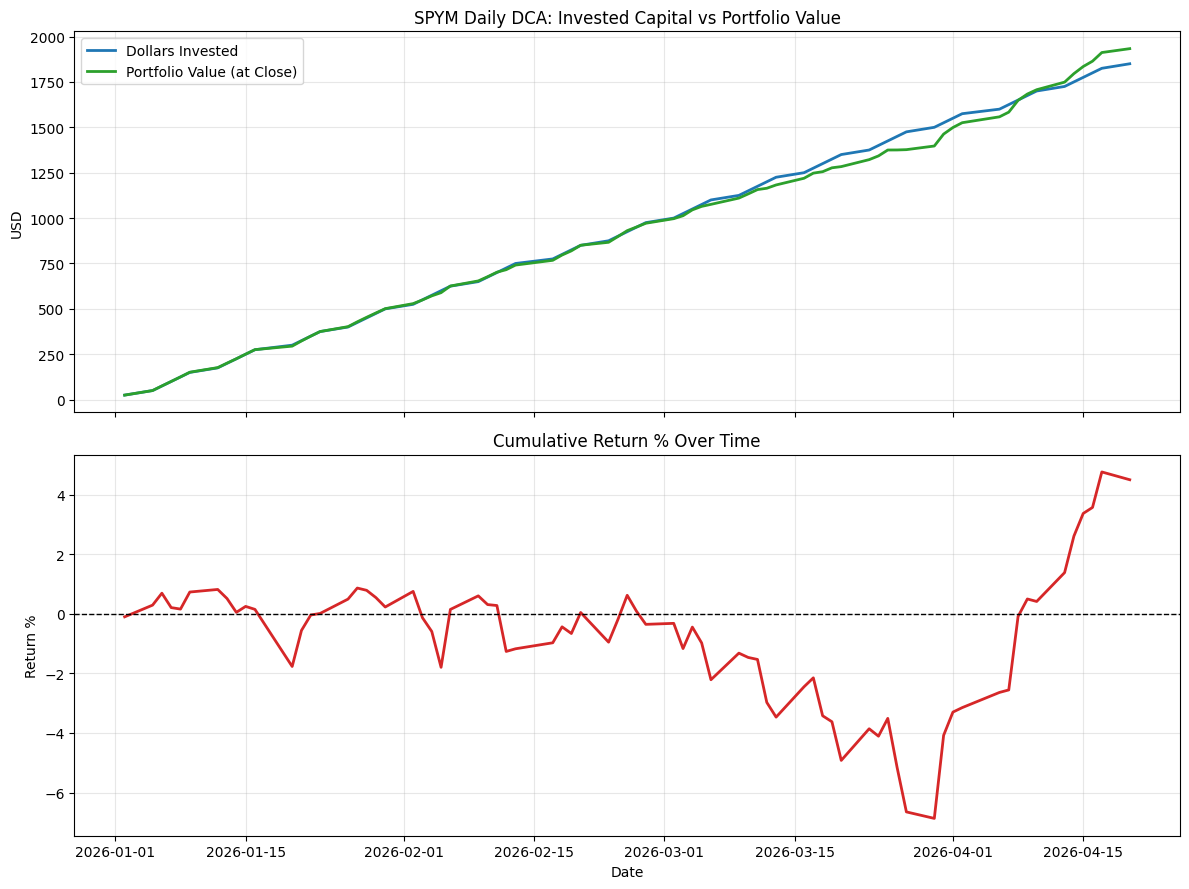

In [5]:
# Visualize growth of invested dollars vs. portfolio value and return %.
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].plot(
    analysis_df['Date'],
    analysis_df['dollars_invested_cumulative'],
    label='Dollars Invested',
    linewidth=2,
    color='#1f77b4',
)
axes[0].plot(
    analysis_df['Date'],
    analysis_df['portfolio_value'],
    label='Portfolio Value (at Close)',
    linewidth=2,
    color='#2ca02c',
)
axes[0].set_title(f'{ticker_symbol} Daily DCA: Invested Capital vs Portfolio Value')
axes[0].set_ylabel('USD')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    analysis_df['Date'],
    analysis_df['return_pct'],
    linewidth=2,
    color='#d62728',
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Cumulative Return % Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return %')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Weekly trade amount (USD) for weekday comparison.
weekly_investment_usd = daily_investment_usd * 5

if weekly_investment_usd <= 0:
    raise ValueError('weekly_investment_usd must be greater than 0')

print(f'Weekly investment for weekday backtest: ${weekly_investment_usd:,.2f}')

Weekly investment for weekday backtest: $125.00


Best weekday in this dataset: Tuesday (4.67% return through 2026-04-20)


,Weekday,Trades,Total Invested,Ending Value,Profit/Loss,Return %
0,Monday,14,"$1,750.00","$1,831.18",$81.18,4.64%
1,Tuesday,15,"$1,875.00","$1,962.64",$87.64,4.67%
2,Wednesday,15,"$1,875.00","$1,953.31",$78.31,4.18%
3,Thursday,15,"$1,875.00","$1,960.49",$85.49,4.56%
4,Friday,15,"$1,875.00","$1,958.51",$83.51,4.45%


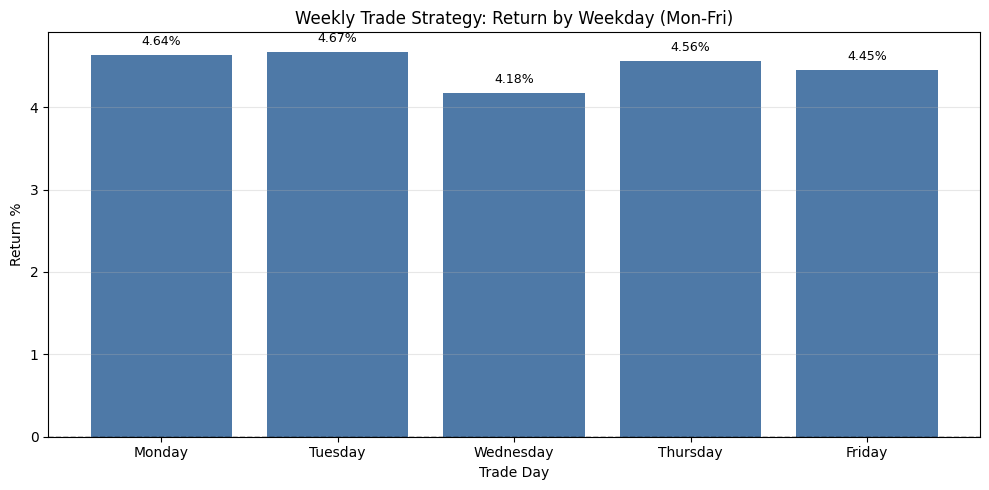

In [7]:
# Compare returns by trading only on one weekday (Mon-Fri).
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
final_close = df['Close'].iloc[-1]
end_date = df['Date'].max()

rows = []
for day in weekday_order:
    day_df = df[df['Weekday'] == day].copy()
    trade_count = len(day_df)
    if trade_count == 0:
        rows.append(
            {
                'Weekday': day,
                'Trades': 0,
                'Total Invested': 0.0,
                'Ending Value': 0.0,
                'Profit/Loss': 0.0,
                'Return %': 0.0,
            }
        )
        continue

    shares = (weekly_investment_usd / day_df['avg_daily_price']).sum()
    invested = weekly_investment_usd * trade_count
    ending_value = shares * final_close
    pnl = ending_value - invested
    ret = (pnl / invested) * 100

    rows.append(
        {
            'Weekday': day,
            'Trades': trade_count,
            'Total Invested': invested,
            'Ending Value': ending_value,
            'Profit/Loss': pnl,
            'Return %': ret,
        }
    )

weekday_results = pd.DataFrame(rows)
weekday_results['Weekday'] = pd.Categorical(
    weekday_results['Weekday'], categories=weekday_order, ordered=True
)
weekday_results = weekday_results.sort_values('Weekday').reset_index(drop=True)

best_row = weekday_results.sort_values('Return %', ascending=False).iloc[0]
print(
    f"Best weekday in this dataset: {best_row['Weekday']} "
    f"({best_row['Return %']:.2f}% return through {end_date.date()})"
)

display_df = weekday_results.copy()
display_df['Total Invested'] = display_df['Total Invested'].map(lambda x: f'${x:,.2f}')
display_df['Ending Value'] = display_df['Ending Value'].map(lambda x: f'${x:,.2f}')
display_df['Profit/Loss'] = display_df['Profit/Loss'].map(lambda x: f'${x:,.2f}')
display_df['Return %'] = display_df['Return %'].map(lambda x: f'{x:,.2f}%')
display(display_df)

plot_df = weekday_results.copy()
colors = ['#4e79a7' if r >= 0 else '#e15759' for r in plot_df['Return %']]

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_df['Weekday'], plot_df['Return %'], color=colors)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.title('Weekly Trade Strategy: Return by Weekday (Mon-Fri)')
plt.ylabel('Return %')
plt.xlabel('Trade Day')
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, plot_df['Return %']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.08 if value >= 0 else -0.25),
        f'{value:.2f}%',
        ha='center',
        va='bottom' if value >= 0 else 'top',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [8]:
# Validate weekday pricing: lower average price implies lower cost day.
price_by_weekday = (
    df.groupby('Weekday', as_index=False)['avg_daily_price']
    .mean()
    .rename(columns={'avg_daily_price': 'Avg Price'})
)

price_by_weekday['Weekday'] = pd.Categorical(
    price_by_weekday['Weekday'], categories=weekday_order, ordered=True
)
price_by_weekday = price_by_weekday.sort_values('Weekday').reset_index(drop=True)

# If weekday return results exist, join them so cost-vs-return is visible together.
if 'weekday_results' in globals():
    weekday_check = price_by_weekday.merge(
        weekday_results[['Weekday', 'Return %']], on='Weekday', how='left'
    )
else:
    weekday_check = price_by_weekday.copy()

lowest_row = weekday_check.loc[weekday_check['Avg Price'].idxmin()]
print(
    f"Lowest average-price day: {lowest_row['Weekday']} "
    f"(${lowest_row['Avg Price']:.4f})"
)

display_df = weekday_check.copy()
display_df['Avg Price'] = display_df['Avg Price'].map(lambda x: f'${x:,.4f}')
if 'Return %' in display_df.columns:
    display_df['Return %'] = display_df['Return %'].map(lambda x: f'{x:,.2f}%')
display(display_df)

Lowest average-price day: Tuesday ($79.7340)


,Weekday,Avg Price,Return %
0,Monday,$79.7788,4.64%
1,Tuesday,$79.7340,4.67%
2,Wednesday,$80.1034,4.18%
3,Thursday,$79.8217,4.56%
4,Friday,$79.9115,4.45%


Top weekday by return: Tuesday (4.67%)


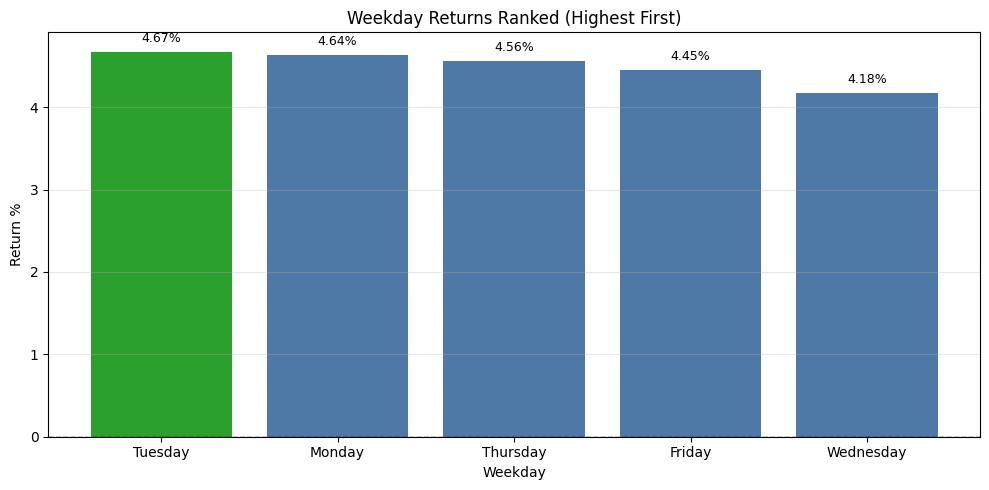

,Weekday,Trades,Total Invested,Ending Value,Profit/Loss,Return %
0,Tuesday,15,1875.0,1962.644684,87.644684,4.67%
1,Monday,14,1750.0,1831.178868,81.178868,4.64%
2,Thursday,15,1875.0,1960.491534,85.491534,4.56%
3,Friday,15,1875.0,1958.505992,83.505992,4.45%
4,Wednesday,15,1875.0,1953.308720,78.308720,4.18%


In [9]:
# Visual: weekdays sorted by return (best to worst).
ranked_returns = weekday_results.sort_values('Return %', ascending=False).reset_index(drop=True)

best_day = ranked_returns.iloc[0]
print(
    f"Top weekday by return: {best_day['Weekday']} ({best_day['Return %']:.2f}%)"
 )

plt.figure(figsize=(10, 5))
colors = ['#2ca02c'] + ['#4e79a7'] * (len(ranked_returns) - 1)
bars = plt.bar(ranked_returns['Weekday'], ranked_returns['Return %'], color=colors)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Weekday Returns Ranked (Highest First)')
plt.ylabel('Return %')
plt.xlabel('Weekday')
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, ranked_returns['Return %']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.08 if value >= 0 else -0.25),
        f'{value:.2f}%',
        ha='center',
        va='bottom' if value >= 0 else 'top',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

display(
    ranked_returns.assign(
        **{'Return %': ranked_returns['Return %'].map(lambda x: f'{x:,.2f}%')}
    )
)

## Weekly Trade Day Analysis (Mon-Fri)
This section compares returns if you placed one trade per week on only one weekday (Monday through Friday) across the same historical window.

## Fidelity Basket Return (This Year Only)
Estimate return for a daily fixed-dollar buy into multiple tickers using this year's data only.

Basket daily investment per ticker: $5.00
Analysis window: 2022 to 2026 (5 years)


,Ticker,Years Covered,Date Range,Days Invested,Total Invested,Ending Value,Profit/Loss,Return %
0,FBCG,5,2022-01-03 to 2026-04-20,1077,"$5,385.00","$9,257.33","$3,872.33",71.91%
1,FMAG,5,2022-01-03 to 2026-04-20,1077,"$5,385.00","$7,634.03","$2,249.03",41.76%
2,MGK,5,2022-01-03 to 2026-04-20,1077,"$5,385.00","$8,626.76","$3,241.76",60.20%
3,OEF,5,2022-01-03 to 2026-04-20,1077,"$5,385.00","$8,304.42","$2,919.42",54.21%
4,QQQ,5,2022-01-03 to 2026-04-20,1077,"$5,385.00","$8,780.37","$3,395.37",63.05%
5,QTOP,3,2024-10-24 to 2026-04-20,371,"$1,855.00","$2,232.41",$377.41,20.35%
6,SPYM,5,2022-01-03 to 2026-04-20,1077,"$5,385.00","$8,006.43","$2,621.43",48.68%
7,TOPT,3,2024-10-24 to 2026-04-20,371,"$1,855.00","$2,119.49",$264.49,14.26%
8,VGT,5,2022-01-03 to 2026-04-20,1077,"$5,385.00","$9,270.77","$3,885.77",72.16%
9,VTI,5,2022-01-03 to 2026-04-20,1077,"$5,385.00","$7,951.63","$2,566.63",47.66%


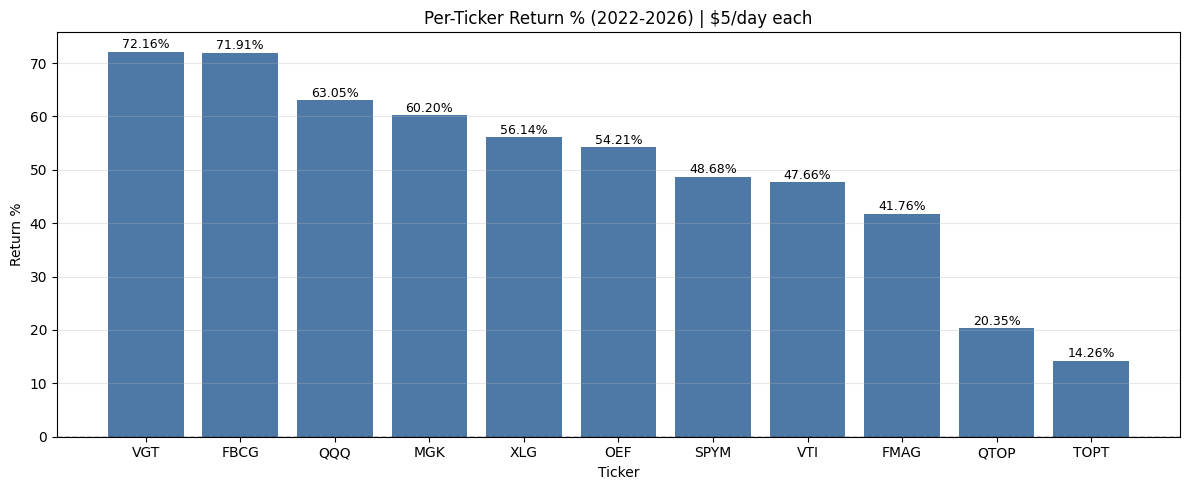

In [10]:
# Basket setup: $5/day per ticker across a multi-year window.
basket_tickers = ['OEF', 'QQQ', 'QTOP', 'SPYM', 'TOPT', 'XLG', 'FBCG', 'FMAG', 'VGT', 'VTI', 'MGK']
basket_daily_investment_usd = 5.0
basket_end_year = data_year  # Uses year selected in Cell 2 by default.
basket_years_back = 5
basket_start_year = basket_end_year - basket_years_back + 1

if basket_daily_investment_usd <= 0:
    raise ValueError('basket_daily_investment_usd must be greater than 0')
if basket_years_back <= 0:
    raise ValueError('basket_years_back must be greater than 0')

results = []
missing_files = []

for symbol in basket_tickers:
    symbol = symbol.strip().upper()
    frames = []

    for year in range(basket_start_year, basket_end_year + 1):
        file_path = tickers_root / symbol / f'{symbol}-{year}.csv'
        if not file_path.exists():
            continue

        tdf_year = pd.read_csv(file_path)
        required_cols = {'Date', 'avg_daily_price', 'Close'}
        missing_cols = required_cols - set(tdf_year.columns)
        if missing_cols:
            print(f"Skipping {symbol}-{year}: missing columns {sorted(missing_cols)}")
            continue

        tdf_year['Date'] = pd.to_datetime(tdf_year['Date'])
        tdf_year = tdf_year.sort_values('Date').reset_index(drop=True)
        frames.append(tdf_year[['Date', 'avg_daily_price', 'Close']])

    if not frames:
        missing_files.append(symbol)
        continue

    tdf = pd.concat(frames, ignore_index=True).sort_values('Date').reset_index(drop=True)
    tdf = tdf[
        (tdf['Date'].dt.year >= basket_start_year) &
        (tdf['Date'].dt.year <= basket_end_year)
    ].reset_index(drop=True)

    if tdf.empty:
        print(f'Skipping {symbol}: no rows in {basket_start_year}-{basket_end_year}')
        continue

    shares = (basket_daily_investment_usd / tdf['avg_daily_price']).sum()
    invested = basket_daily_investment_usd * len(tdf)
    ending_close = tdf['Close'].iloc[-1]
    ending_value = shares * ending_close
    pnl = ending_value - invested
    ret_pct = (pnl / invested) * 100 if invested > 0 else 0.0
    years_covered = sorted(tdf['Date'].dt.year.unique().tolist())

    results.append(
        {
            'Ticker': symbol,
            'Years Covered': len(years_covered),
            'Date Range': f"{tdf['Date'].min().date()} to {tdf['Date'].max().date()}",
            'Days Invested': len(tdf),
            'Total Invested': invested,
            'Ending Value': ending_value,
            'Profit/Loss': pnl,
            'Return %': ret_pct,
        }
    )

if missing_files:
    print(
        f"No usable files found for {basket_start_year}-{basket_end_year}: "
        f"{', '.join(missing_files)}"
    )

if not results:
    raise ValueError('No basket results were computed. Check ticker names and data files.')

basket_df = pd.DataFrame(results).sort_values('Ticker').reset_index(drop=True)

portfolio_invested = basket_df['Total Invested'].sum()
portfolio_value = basket_df['Ending Value'].sum()
portfolio_pnl = portfolio_value - portfolio_invested
portfolio_return_pct = (portfolio_pnl / portfolio_invested) * 100 if portfolio_invested > 0 else 0.0

portfolio_total = pd.DataFrame(
    [
        {
            'Ticker': 'TOTAL',
            'Years Covered': '-',
            'Date Range': f"{basket_start_year}-01-01 to {basket_end_year}-12-31",
            'Days Invested': int(basket_df['Days Invested'].sum()),
            'Total Invested': portfolio_invested,
            'Ending Value': portfolio_value,
            'Profit/Loss': portfolio_pnl,
            'Return %': portfolio_return_pct,
        }
    ]
)

display_df = pd.concat([basket_df, portfolio_total], ignore_index=True)
display_df['Total Invested'] = display_df['Total Invested'].map(lambda x: f'${x:,.2f}')
display_df['Ending Value'] = display_df['Ending Value'].map(lambda x: f'${x:,.2f}')
display_df['Profit/Loss'] = display_df['Profit/Loss'].map(lambda x: f'${x:,.2f}')
display_df['Return %'] = display_df['Return %'].map(lambda x: f'{x:,.2f}%')

print(f'Basket daily investment per ticker: ${basket_daily_investment_usd:,.2f}')
print(f'Analysis window: {basket_start_year} to {basket_end_year} ({basket_years_back} years)')
display(display_df)

# Optional: quick visual for per-ticker return percentages (excluding TOTAL), sorted high to low.
plot_df = basket_df.sort_values('Return %', ascending=False).reset_index(drop=True)
plt.figure(figsize=(12, 5))
bars = plt.bar(plot_df['Ticker'], plot_df['Return %'], color='#4e79a7')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title(
    f'Per-Ticker Return % ({basket_start_year}-{basket_end_year}) | '
    f'${basket_daily_investment_usd:.0f}/day each'
    )
plt.ylabel('Return %')
plt.xlabel('Ticker')
plt.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, plot_df['Return %']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.08 if value >= 0 else -0.25),
        f'{value:.2f}%',
        ha='center',
        va='bottom' if value >= 0 else 'top',
        fontsize=9,
    )

plt.tight_layout()
plt.show()